In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Reproducibilidade
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")


Dispositivo utilizado: cpu


In [2]:

# ── Carregamento dos dados ──────────────────────────────────────────────────
DATA_DIR = r"Fashion MNIST"

train_df = pd.read_csv(f"{DATA_DIR}/fashion-mnist_train.csv")
test_df  = pd.read_csv(f"{DATA_DIR}/fashion-mnist_test.csv")

# Separar pixels dos rótulos
X_train = train_df.drop("label", axis=1).values.astype(np.float32) / 255.0
X_test  = test_df.drop("label", axis=1).values.astype(np.float32)  / 255.0

# Reshape para (N, 1, 28, 28) — formato esperado por camadas convolucionais
X_train = X_train.reshape(-1, 1, 28, 28)
X_test  = X_test.reshape(-1, 1, 28, 28)

train_tensor = torch.tensor(X_train)
test_tensor  = torch.tensor(X_test)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=256, shuffle=True)
test_loader  = DataLoader(TensorDataset(test_tensor),  batch_size=256, shuffle=False)

print(f"Treino : {X_train.shape}")
print(f"Teste  : {X_test.shape}")


Treino : (60000, 1, 28, 28)
Teste  : (10000, 1, 28, 28)


In [3]:

# ── Arquitetura Convolucional do Autoencoder ────────────────────────────────
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: 28x28 → espaço latente (4x4x32 = 512 → projetado em 64 dims)
        self.encoder = nn.Sequential(
            # Bloco 1: 1×28×28 → 16×14×14
            nn.Conv2d(1, 16, kernel_size=3, padding=1),   # 1×28×28 → 16×28×28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # → 16×14×14

            # Bloco 2: 16×14×14 → 32×7×7
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # → 32×14×14
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # → 32×7×7

            # Bloco 3: 32×7×7 → 64×4×4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # → 64×7×7
            nn.ReLU(),
            nn.MaxPool2d(2, 2, padding=1),                 # → 64×4×4
        )

        # Decoder: 64×4×4 → 1×28×28
        self.decoder = nn.Sequential(
            # Bloco 1: 64×4×4 → 32×7×7
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # → 32×8×8... ajuste abaixo
            nn.ReLU(),
            # output_size fica 8×8 por conta do padding no encoder, usa crop interno via output_padding

            # Bloco 2: 32×8×8 → 16×14×14  (ou 16×16 — ajustamos com output_padding)
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),

            # Bloco 3: 16×... → 1×28×28
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid(),   # pixels entre 0 e 1
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        # Garante dimensão 28×28 (caso haja diferença de 1 pixel por padding)
        x_hat = nn.functional.interpolate(x_hat, size=(28, 28), mode="bilinear", align_corners=False)
        return x_hat


model = ConvAutoencoder().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal de parâmetros: {total_params:,}")


ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)

Total de parâmetros: 33,649


In [4]:

# ── Treinamento ─────────────────────────────────────────────────────────────
EPOCHS    = 30
LR        = 1e-3

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for (batch,) in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        output = model(batch)
        loss   = criterion(output, batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f"Época {epoch:>3}/{EPOCHS}  |  MSE médio: {epoch_loss:.6f}")

print("\nTreinamento concluído.")


Época   1/30  |  MSE médio: 0.075177
Época   5/30  |  MSE médio: 0.012629
Época  10/30  |  MSE médio: 0.010370
Época  15/30  |  MSE médio: 0.009632
Época  20/30  |  MSE médio: 0.009101
Época  25/30  |  MSE médio: 0.008831
Época  30/30  |  MSE médio: 0.008631

Treinamento concluído.


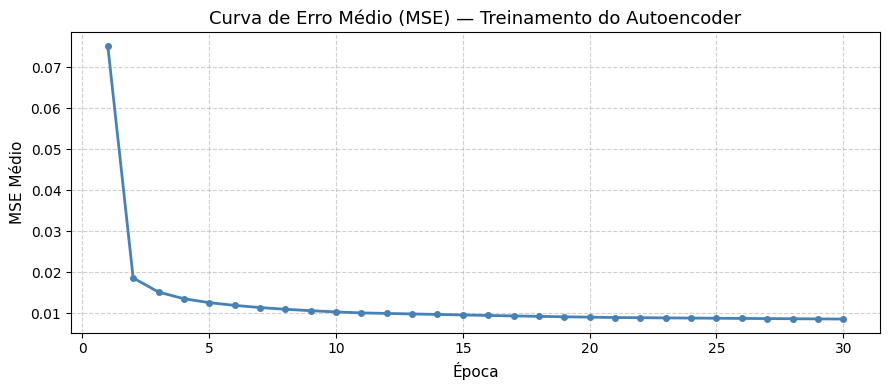

In [5]:

# ── Curva de Erro Médio (MSE) ao longo do Treinamento ───────────────────────
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", markersize=4,
         color="steelblue", linewidth=2)
plt.title("Curva de Erro Médio (MSE) — Treinamento do Autoencoder", fontsize=13)
plt.xlabel("Época", fontsize=11)
plt.ylabel("MSE Médio", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


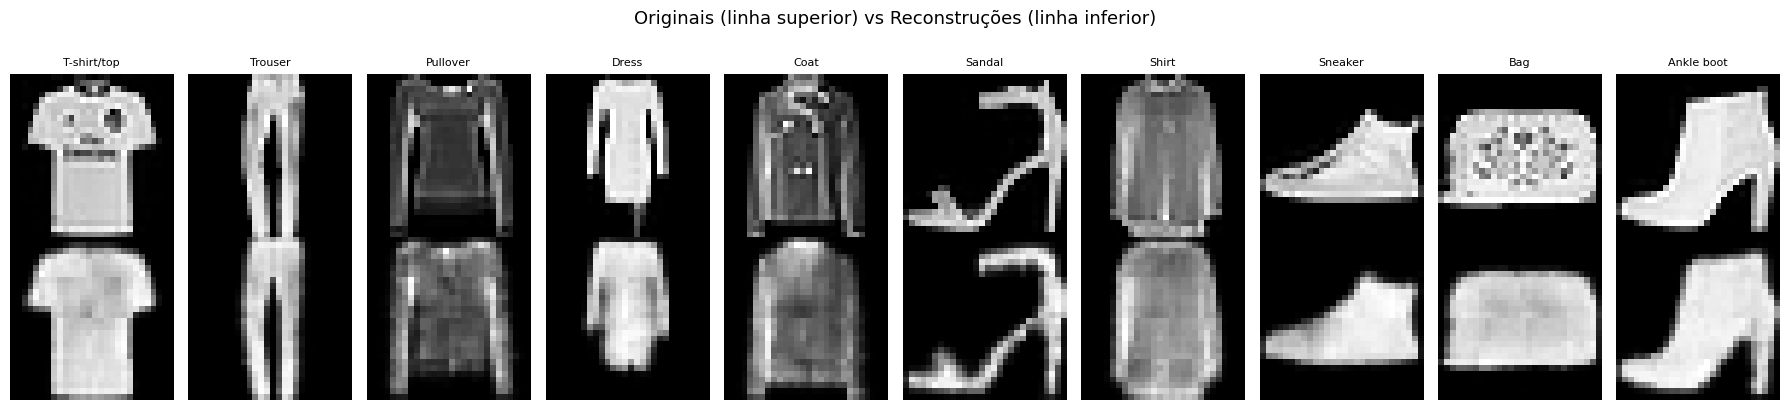

In [6]:

# ── Reconstrução de 10 imagens do conjunto de teste ─────────────────────────
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

model.eval()
N = 10

# Pegar as 10 primeiras imagens do teste (uma por classe, se possível)
y_test = test_df["label"].values
sample_indices = []
for cls in range(10):
    idx = np.where(y_test == cls)[0][0]
    sample_indices.append(idx)

originals = test_tensor[sample_indices].to(device)   # (10, 1, 28, 28)

with torch.no_grad():
    reconstructions = model(originals).cpu().numpy()  # (10, 1, 28, 28)

originals_np = originals.cpu().numpy()

fig, axes = plt.subplots(2, N, figsize=(18, 4))
fig.suptitle("Originais (linha superior) vs Reconstruções (linha inferior)",
             fontsize=13, y=1.02)

for i in range(N):
    # Original
    axes[0, i].imshow(originals_np[i, 0], cmap="gray")
    axes[0, i].set_title(CLASS_NAMES[i], fontsize=8)
    axes[0, i].axis("off")

    # Reconstrução
    axes[1, i].imshow(reconstructions[i, 0], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original",      fontsize=10, rotation=90, labelpad=5)
axes[1, 0].set_ylabel("Reconstrução",  fontsize=10, rotation=90, labelpad=5)

plt.tight_layout()
plt.show()



## 4(b) — Denoising Autoencoder

O objetivo é treinar um *denoising autoencoder*: a rede recebe imagens **corrompidas por ruído gaussiano** e deve reconstruir as imagens **originais sem ruído**. A arquitetura é idêntica ao autoencoder da letra (a), mas agora a entrada é a versão ruidosa e o alvo é a versão limpa.


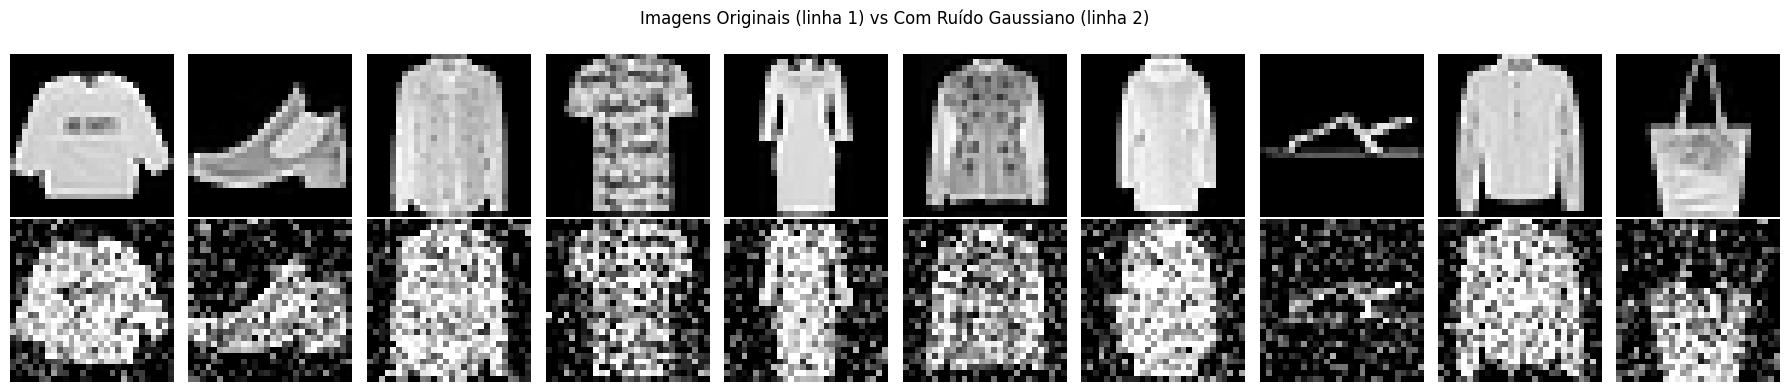

Fator de ruído gaussiano: 0.3


In [7]:

# ── Função de adição de ruído gaussiano ────────────────────────────────────
def add_gaussian_noise(tensor, noise_factor=0.3):
    """Adiciona ruído gaussiano e mantém os valores entre 0 e 1."""
    noise = torch.randn_like(tensor) * noise_factor
    return torch.clamp(tensor + noise, 0.0, 1.0)

NOISE_FACTOR = 0.3

# DataLoaders para o denoising: (noisy, clean)
class NoisyDataset(torch.utils.data.Dataset):
    def __init__(self, clean_tensor, noise_factor=0.3):
        self.clean = clean_tensor
        self.noise_factor = noise_factor

    def __len__(self):
        return len(self.clean)

    def __getitem__(self, idx):
        clean = self.clean[idx]
        noisy = add_gaussian_noise(clean.unsqueeze(0), self.noise_factor).squeeze(0)
        return noisy, clean

noisy_train_ds = NoisyDataset(train_tensor, NOISE_FACTOR)
noisy_test_ds  = NoisyDataset(test_tensor,  NOISE_FACTOR)

noisy_train_loader = DataLoader(noisy_train_ds, batch_size=256, shuffle=True)
noisy_test_loader  = DataLoader(noisy_test_ds,  batch_size=256, shuffle=False)

# Exibir exemplos de imagens com ruído
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Imagens Originais (linha 1) vs Com Ruído Gaussiano (linha 2)", fontsize=12)

for i in range(10):
    clean_ex = train_tensor[i, 0].numpy()
    noisy_ex = add_gaussian_noise(train_tensor[i], NOISE_FACTOR).numpy()[0]
    axes[0, i].imshow(clean_ex, cmap="gray");  axes[0, i].axis("off")
    axes[1, i].imshow(noisy_ex, cmap="gray");  axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original",  fontsize=9, rotation=90, labelpad=5)
axes[1, 0].set_ylabel("Com Ruído", fontsize=9, rotation=90, labelpad=5)
plt.tight_layout()
plt.show()

print(f"Fator de ruído gaussiano: {NOISE_FACTOR}")


In [8]:

# ── Denoising Autoencoder — mesma arquitetura, treinamento diferente ────────
denoiser = ConvAutoencoder().to(device)

EPOCHS_DN = 30
LR_DN     = 1e-3

criterion_dn = nn.MSELoss()
optimizer_dn = optim.Adam(denoiser.parameters(), lr=LR_DN)
scheduler_dn = optim.lr_scheduler.StepLR(optimizer_dn, step_size=10, gamma=0.5)

dn_losses = []

for epoch in range(1, EPOCHS_DN + 1):
    denoiser.train()
    running_loss = 0.0

    for noisy_batch, clean_batch in noisy_train_loader:
        noisy_batch = noisy_batch.to(device)
        clean_batch = clean_batch.to(device)

        optimizer_dn.zero_grad()
        output = denoiser(noisy_batch)          # reconstrução a partir de imagem ruidosa
        loss   = criterion_dn(output, clean_batch)   # comparado com imagem LIMPA
        loss.backward()
        optimizer_dn.step()
        running_loss += loss.item() * noisy_batch.size(0)

    epoch_loss = running_loss / len(noisy_train_loader.dataset)
    dn_losses.append(epoch_loss)
    scheduler_dn.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f"Época {epoch:>3}/{EPOCHS_DN}  |  MSE médio (denoising): {epoch_loss:.6f}")

print("\nTreinamento do Denoising Autoencoder concluído.")


Época   1/30  |  MSE médio (denoising): 0.044556
Época   5/30  |  MSE médio (denoising): 0.017694
Época  10/30  |  MSE médio (denoising): 0.015395
Época  15/30  |  MSE médio (denoising): 0.014598
Época  20/30  |  MSE médio (denoising): 0.014069
Época  25/30  |  MSE médio (denoising): 0.013767
Época  30/30  |  MSE médio (denoising): 0.013553

Treinamento do Denoising Autoencoder concluído.


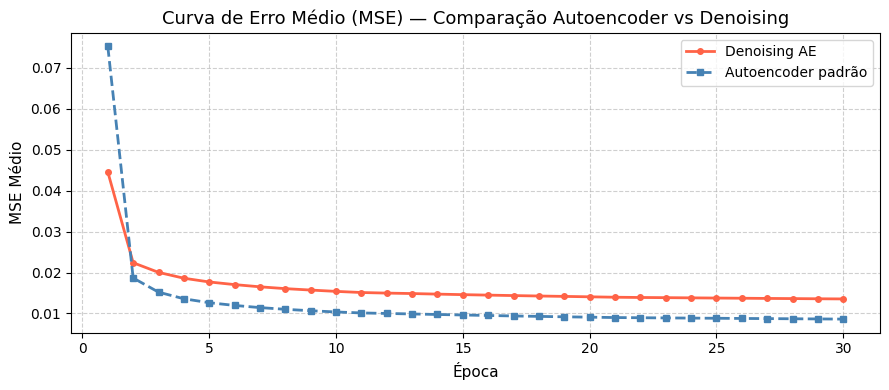

In [9]:

# ── Curva de Erro Médio — Denoising Autoencoder ─────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS_DN + 1), dn_losses, marker="o", markersize=4,
         color="tomato", linewidth=2, label="Denoising AE")
plt.plot(range(1, EPOCHS + 1),    train_losses, marker="s", markersize=4,
         color="steelblue", linewidth=2, linestyle="--", label="Autoencoder padrão")
plt.title("Curva de Erro Médio (MSE) — Comparação Autoencoder vs Denoising", fontsize=13)
plt.xlabel("Época", fontsize=11)
plt.ylabel("MSE Médio", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


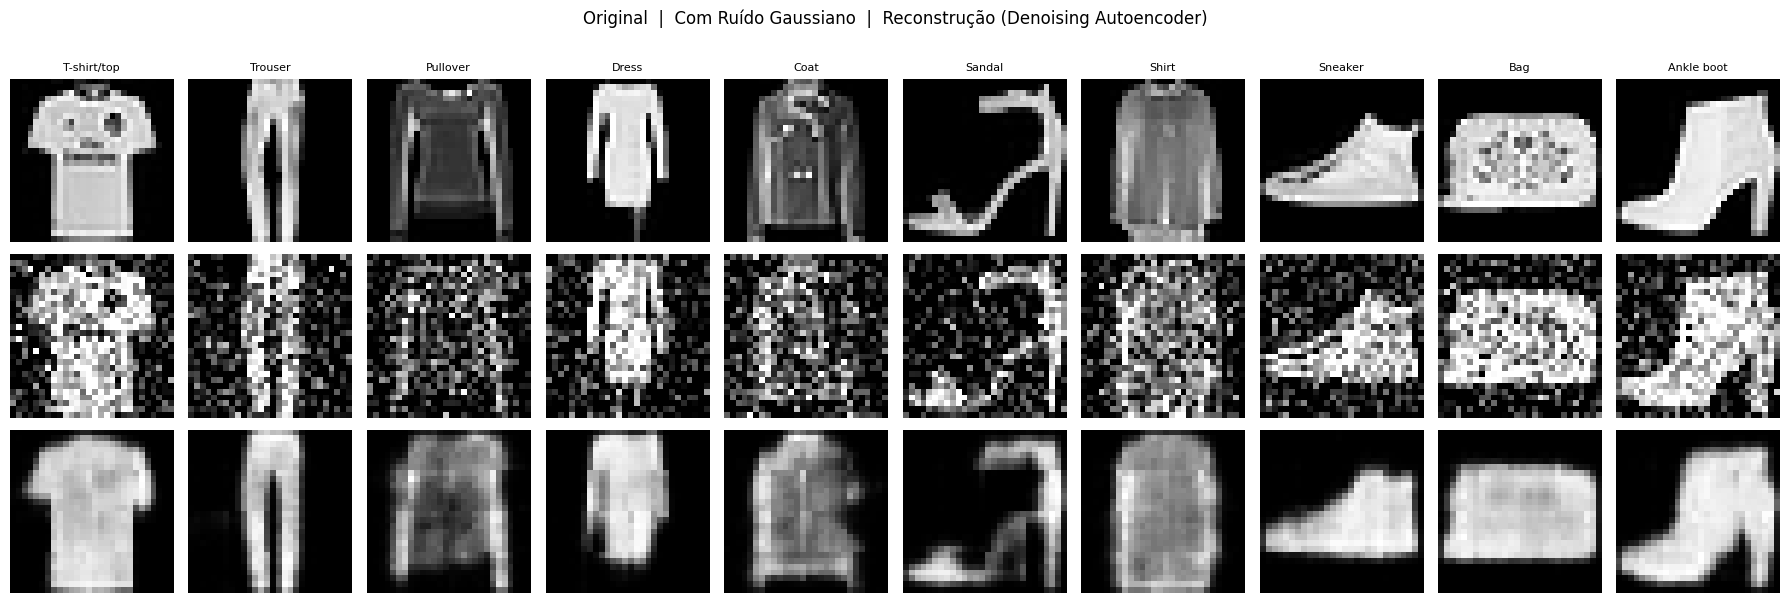

In [10]:

# ── Visualização: Original | Com Ruído | Denoised ───────────────────────────
# Reutiliza as mesmas 10 imagens (uma por classe) selecionadas na questão (a)
torch.manual_seed(0)   # ruído fixo para reprodutibilidade

clean_samples = test_tensor[sample_indices]                                    # (10, 1, 28, 28)
noisy_samples = add_gaussian_noise(clean_samples, NOISE_FACTOR)               # (10, 1, 28, 28)

denoiser.eval()
with torch.no_grad():
    denoised_samples = denoiser(noisy_samples.to(device)).cpu()                # (10, 1, 28, 28)

clean_np   = clean_samples.numpy()
noisy_np   = noisy_samples.numpy()
denoised_np = denoised_samples.numpy()

fig, axes = plt.subplots(3, N, figsize=(18, 6))
fig.suptitle(
    "Original  |  Com Ruído Gaussiano  |  Reconstrução (Denoising Autoencoder)",
    fontsize=12, y=1.01
)

row_labels = ["Original", "Com Ruído", "Reconstruída"]

for i in range(N):
    axes[0, i].imshow(clean_np[i, 0],   cmap="gray")
    axes[1, i].imshow(noisy_np[i, 0],   cmap="gray")
    axes[2, i].imshow(denoised_np[i, 0], cmap="gray")
    axes[0, i].set_title(CLASS_NAMES[i], fontsize=8)
    for row in range(3):
        axes[row, i].axis("off")

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=5)

plt.tight_layout()
plt.show()
